In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

plt.style.use('ggplot')
sns.set_style('whitegrid')


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


AttributeError: module 'matplotlib' has no attribute 'get_data_path'

In [5]:
df = pd.read_csv("/Users/sidhaanthkapoor/MentalHealthClassifier/data/raw/Combined_Data.csv")
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [6]:
print("Number of rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

df.info()

Number of rows: 53043
Number of Columns: 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [7]:
df.describe(include='all')

,Unnamed: 0,statement,status
count,53043.000000,52681,53043
unique,NaN,51073,7
top,NaN,what do you mean?,Normal
freq,NaN,22,16351
mean,26521.000000,NaN,NaN
std,15312.339501,NaN,NaN
min,0.000000,NaN,NaN
25%,13260.500000,NaN,NaN
50%,26521.000000,NaN,NaN
75%,39781.500000,NaN,NaN


In [8]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

NameError: name 'plt' is not defined

In [10]:
duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

Duplicates: 0


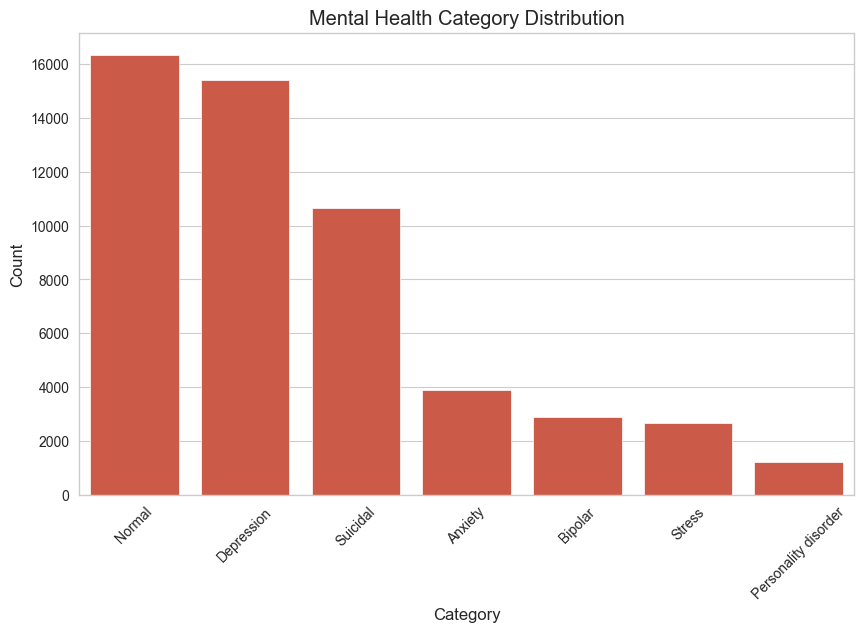

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="status", order=df['status'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Mental Health Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.savefig("/Users/sidhaanthkapoor/MentalHealthClassifier/data/processed/mental_health_category_distribution.png")
plt.show()

In [15]:
df["status"].value_counts(normalize=True).mul(100).round(2)

status
Normal                  30.83
Depression              29.04
Suicidal                20.08
Anxiety                  7.33
Bipolar                  5.42
Stress                   5.03
Personality disorder     2.26
Name: proportion, dtype: float64

In [18]:
df["char_length"] = df["statement"].str.len()
df["char_length"].describe()

count    52681.000000
mean       578.713863
std        846.269078
min          2.000000
25%         80.000000
50%        317.000000
75%        752.000000
max      32759.000000
Name: char_length, dtype: float64

In [19]:
df["word_length"] = df["statement"].str.split().str.len()

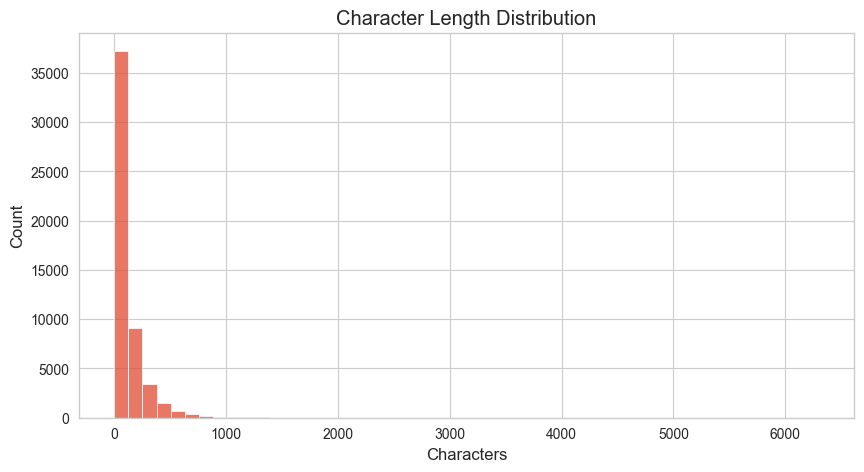

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(df["word_length"], bins=50)
plt.title("Character Length Distribution")
plt.xlabel("Characters")
plt.show()

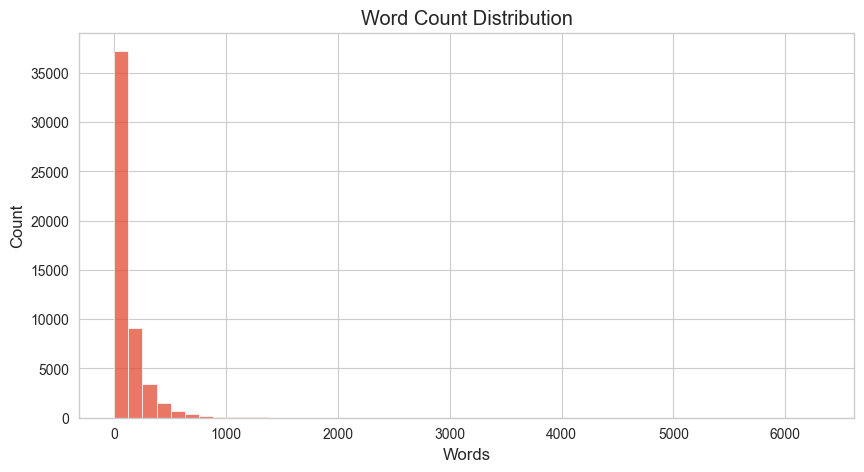

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df["word_length"], bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.show()

In [2]:
top = df.head(20)
plt.figure(figsize=(12,6))
plt.bar(top["Word"], top["Count"])
plt.xticks(rotation=60)
plt.title("Top 20 Most Frequent Words")
plt.show()

NameError: name 'df' is not defined